In [2]:
import numpy as np
lowlou_f = "/workspaces/template_pytorch/rtmag/lowlou/test/b_0.210_0.124.npz"
data = np.load(lowlou_f)


print(data.files)  

b = data["b"]
print(b.shape)


with np.load(lowlou_f) as data:
    for key in data.files:
        print(key, data[key].shape, data[key].dtype)

['b']
(64, 64, 64, 3)
b (64, 64, 64, 3) float64


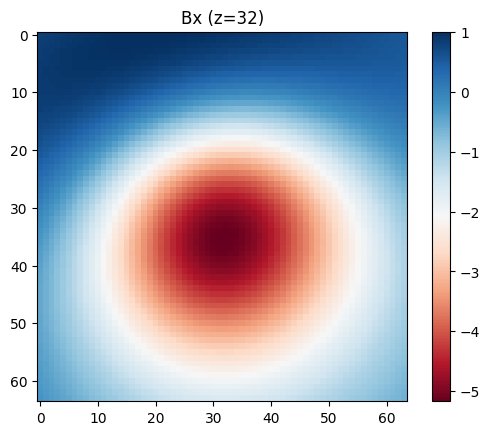

In [3]:
import matplotlib.pyplot as plt

bx = b[..., 0]  # x成分 (64,64,64)
by = b[..., 1]  # y成分 (64,64,64)
bz = b[..., 2]  # z成分 (64,64,64)
k = 32 
plt.imshow(bz[:, :, k], cmap="RdBu")
plt.colorbar()
plt.title("Bx (z=32)")
plt.show()


In [4]:
import torch
b_tensor = torch.from_numpy(b)
b_tensor = b_tensor.unsqueeze(0)

print(b_tensor.shape)

torch.Size([1, 64, 64, 64, 3])


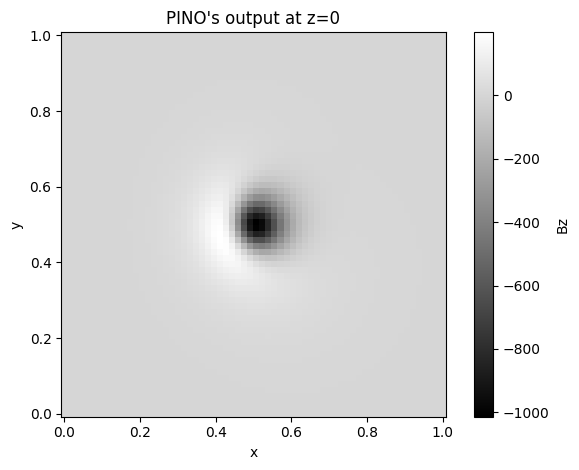

In [5]:
import matplotlib.pyplot as plt

bottom = b[:, :, 0, 2]

nx, ny, nz = bx.shape
x = np.linspace(0, 1, nx)  # 単位はあとで変換できる
y = np.linspace(0, 1, ny)

X, Y = np.meshgrid(x, y, indexing="ij")
bottom = bz[:, :, 0]   # z=0平面の Bz

# bottom はすでに (64,64)
fig, ax = plt.subplots()
pcm = ax.pcolormesh(X, Y, bottom, cmap='gray')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.set_title("PINO's output at z=0")

fig.colorbar(pcm, ax=ax, label="Bz")  
plt.tight_layout()
plt.show()


/tmp/ipykernel_7928/702659741.py:9: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(pcm, ax=ax, label="Bz")


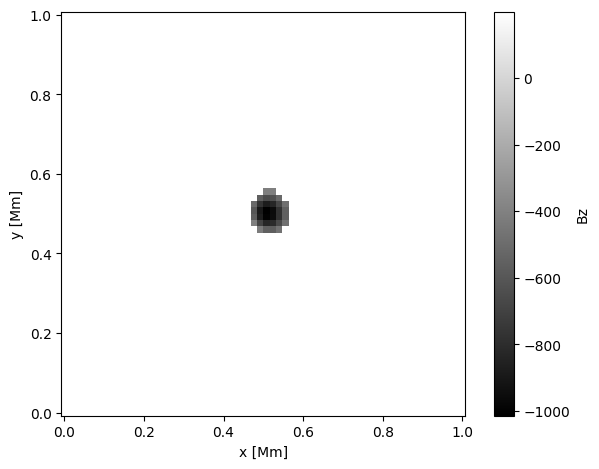

[[30 30  0]
 [30 31  0]
 [30 32  0]
 [30 33  0]
 [31 29  0]
 [31 30  0]
 [31 31  0]
 [31 32  0]
 [31 33  0]
 [31 34  0]
 [32 29  0]
 [32 30  0]
 [32 31  0]
 [32 32  0]
 [32 33  0]
 [32 34  0]
 [32 35  0]
 [33 29  0]
 [33 30  0]
 [33 31  0]
 [33 32  0]
 [33 33  0]
 [33 34  0]
 [33 35  0]
 [34 29  0]
 [34 30  0]
 [34 31  0]
 [34 32  0]
 [34 33  0]
 [34 34  0]
 [35 30  0]
 [35 31  0]
 [35 32  0]
 [35 33  0]]


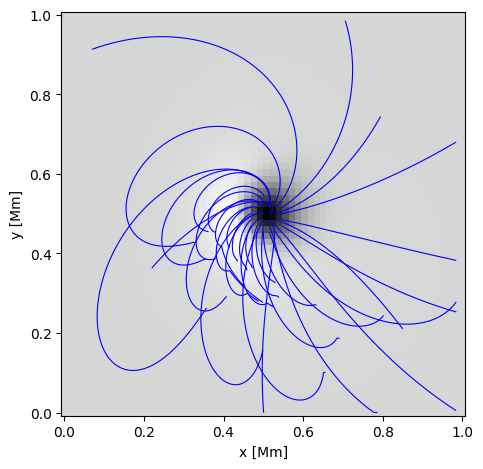

In [10]:
from streamtracer import StreamTracer, VectorGrid

mask = np.abs(bottom) > 500
fig, ax = plt.subplots()
ax.pcolormesh(x, y, (bottom*mask).T, cmap='gray')
ax.set_xlabel('x [Mm]')
ax.set_ylabel('y [Mm]')
ax.set_aspect('equal')
fig.colorbar(pcm, ax=ax, label="Bz")  
plt.tight_layout()
plt.show()

stride = 1
seeds = np.stack([np.where(mask == True)[0], 
                  np.where(mask == True)[1], 
                  np.zeros_like(np.where(mask == True)[0])], axis=1)
seeds = seeds[::stride]
print(seeds)
seeds.shape

nsteps = 10000
step_size = 0.1
grid_spacing = [1, 1, 1]

grid = VectorGrid(b.astype(np.float64), grid_spacing)
tracer = StreamTracer(nsteps, step_size)
tracer_xs = []
tracer.trace(seeds, grid)
tracer_xs.append(tracer.xs)
tracer_xs = [item for sublist in tracer_xs for item in sublist]

dx = 1/64
dy = 1/64

fig, ax = plt.subplots()
ax.pcolormesh(x, y, bottom.T, cmap='gray')
ax.set_xlabel('x [Mm]')
ax.set_ylabel('y [Mm]')
ax.set_aspect('equal')
for i, xl in enumerate(tracer_xs):
    assert seeds[i] in xl 
    ax.plot(xl[:,0]*dx+x[0], xl[:,1]*dy+y[0], color='blue', linewidth=0.8)
plt.tight_layout()
plt.show()